# LFHE — Loss Function Hypothesis Experiment

**Read-only visualization** of MSE vs DA-MSE on CSRLE B0-LC.

Execute cells sequentially. Change **`SELECTED_CONTAINER`** in Section 6 to visualize any container, then re-run Sections 7–9.


## 1 — Experiment overview


In [1]:
import json
import sys
from pathlib import Path

%matplotlib inline

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Update this path if re-running against a different LFHE timestamp
LFHE_EXP = REPO_ROOT / 'experiments' / 'loss_function_hypothesis_2026-07-26_130252'
MSE_DIR = LFHE_EXP / 'b0_lc_mse'
DA_DIR = LFHE_EXP / 'b0_lc_da_mse'
SAVE_FIGS = False
FIG_DIR = LFHE_EXP / 'plots'
print('LFHE experiment:', LFHE_EXP)


LFHE experiment: /Users/lehaan/Desktop/FYP_Long_Term/experiments/loss_function_hypothesis_2026-07-26_130252


## 2 — Load frozen artifacts


In [2]:
import pandas as pd

with (LFHE_EXP / 'config' / 'lfhe_config_frozen.json').open() as fh:
    cfg = json.load(fh)
with (LFHE_EXP / 'reports' / 'final_report.json').open() as fh:
    final_report = json.load(fh)

CSRLE_EXP = REPO_ROOT / cfg['csrle_experiment_dir']

mse_ext = pd.read_csv(MSE_DIR / 'evaluation' / 'extended_metrics.csv')
da_ext = pd.read_csv(DA_DIR / 'evaluation' / 'extended_metrics.csv')
mse_hist = pd.read_csv(MSE_DIR / 'training' / 'training_history.csv')
da_hist = pd.read_csv(DA_DIR / 'training' / 'training_history.csv')
hv_cohort = pd.read_csv(LFHE_EXP / 'diagnostics' / 'horizon_variance_recovery_cohort.csv')
hv_pc = pd.read_csv(LFHE_EXP / 'diagnostics' / 'horizon_variance_recovery_per_container.csv')
ec_cohort = pd.read_csv(LFHE_EXP / 'diagnostics' / 'energy_recovery_cohort.csv')
ec_pc = pd.read_csv(LFHE_EXP / 'diagnostics' / 'energy_recovery_per_container.csv')
summary = pd.read_csv(LFHE_EXP / 'tables' / 'lfhe_summary.csv')
ALL_CONTAINERS = sorted(mse_ext['container_id'].astype(str).unique())
display(summary)


,arm,pearson_r_mean,std_ratio_mean,mae_mean,rmse_mean,r2_mean
0,mse,0.113331,0.100676,0.093231,0.137439,-0.320658
1,da_mse,0.087417,0.826784,0.104654,0.149062,-2.389407


## 3 — Verify frozen configuration


In [3]:
print('Protocol:', cfg['protocol_version'])
print('λ (frozen):', cfg['lambda_disp'])
print('Reproduction gate:', final_report['reproduction_gate']['pass'])
print('Hypothesis verdict:', final_report['hypothesis_verdict']['verdict'])


Protocol: lfhe_v1.1
λ (frozen): 1.0
Reproduction gate: True
Hypothesis verdict: inconclusive_I1


## 4 — Load MSE reference (Stage 2 via reproduction gate)


In [4]:
repro = final_report['reproduction_gate']
print('Stage 2 B0 reference (frozen weights eval):')
for k, v in repro['cohort_gate']['checks'].items():
    if 'stage2_reference' in v:
        print(f'  {k}: {v["stage2_reference"]:.4f}')


Stage 2 B0 reference (frozen weights eval):
  residual_pearson_r: 0.0841
  residual_std_ratio: 0.0730
  residual_mae_scaled: 0.0936
  residual_rmse_scaled: 0.1378
  residual_r2: -0.3322


## 5 — Load DA-MSE experiment


In [5]:
with (DA_DIR / 'training' / 'training_metadata.json').open() as fh:
    da_meta = json.load(fh)
print('DA-MSE best epoch:', da_meta['best_epoch'], 'best val loss:', da_meta['best_val_loss'])


DA-MSE best epoch: 7 best val loss: 2.436884641647339


## 6 — Container selector

Set **`SELECTED_CONTAINER`** to any `container_id` from the browse table, or leave **`None`** for the auto representative (median |r| on DA-MSE).

**Examples:**
```python
SELECTED_CONTAINER = None          # auto
SELECTED_CONTAINER = 'c_10733'     # specific container
```

After changing, re-run this cell and Sections 7–9.


In [6]:
from utils.csrle.stage2_plots import select_representative_container

# ── Change this line to pick a container ──
SELECTED_CONTAINER = None  # e.g. 'c_10733'

metric_cols = [
    'residual_pearson_r', 'residual_std_ratio',
    'residual_mae_scaled', 'residual_r2',
]
browse = da_ext[['container_id'] + metric_cols].merge(
    mse_ext[['container_id'] + metric_cols],
    on='container_id', suffixes=('_da', '_mse'),
)
browse['delta_r'] = browse['residual_pearson_r_da'] - browse['residual_pearson_r_mse']
browse['delta_std_ratio'] = browse['residual_std_ratio_da'] - browse['residual_std_ratio_mse']
browse = browse.sort_values('container_id')

print(f'Available containers: {len(browse)}')
print('Top 10 by DA-MSE std ratio gain:')
display(browse.nlargest(10, 'delta_std_ratio')[
    ['container_id', 'residual_pearson_r_mse', 'residual_pearson_r_da',
     'residual_std_ratio_mse', 'residual_std_ratio_da', 'delta_std_ratio']
])

if SELECTED_CONTAINER is None:
    SELECTED_CONTAINER = select_representative_container(da_ext)
elif str(SELECTED_CONTAINER) not in ALL_CONTAINERS:
    raise ValueError(
        f'Unknown container {SELECTED_CONTAINER!r}. '
        f'Choose from ALL_CONTAINERS ({len(ALL_CONTAINERS)} ids).'
    )

SELECTED_CONTAINER = str(SELECTED_CONTAINER)
print('\n>>> Visualizing container:', SELECTED_CONTAINER)
display(browse.loc[browse['container_id'] == SELECTED_CONTAINER].T)


Available containers: 99
Top 10 by DA-MSE std ratio gain:


,container_id,residual_pearson_r_mse,residual_pearson_r_da,residual_std_ratio_mse,residual_std_ratio_da,delta_std_ratio
50,c_13308,-0.164054,-0.188254,0.427881,9.103042,8.675161
95,c_15794,-0.082662,-0.099616,0.325845,8.048925,7.723080
6,c_10312,0.381468,0.367185,0.230455,3.562395,3.331940
70,c_14435,0.202281,0.193488,0.158032,2.508506,2.350474
65,c_14388,-0.059427,-0.022393,0.092536,2.044167,1.951632
59,c_1387,-0.028658,0.159530,0.088626,1.748061,1.659435
9,c_10641,-0.070370,-0.012850,0.110035,1.414003,1.303967
88,c_15570,-0.083020,-0.198726,0.130916,1.391245,1.260330
4,c_1016,0.258289,0.332477,0.060366,1.238198,1.177832
55,c_13615,-0.071148,-0.116427,0.115947,1.227617,1.111670



>>> Visualizing container: c_15035


,78
container_id,c_15035
residual_pearson_r_da,0.089665
residual_std_ratio_da,0.117863
residual_mae_scaled_da,0.084439
residual_r2_da,0.005697
residual_pearson_r_mse,0.049579
residual_std_ratio_mse,0.005114
residual_mae_scaled_mse,0.065401
residual_r2_mse,-0.001284
delta_r,0.040086


## 7 — Inference setup (cached models & data)


In [7]:
from utils.csrle.stage2_metrics import actual_predicted_residual_arrays, horizon_band_metrics
from utils.csrle.stage2_training import build_condition_scalers, load_condition_frames
from utils.lfhe.artifacts import load_lfhe_arm_artifacts
from utils.hybrid_inference import run_hybrid_inference

_train_df, _val_df = load_condition_frames(CSRLE_EXP, 'b0_lc')
_scalers = build_condition_scalers(_train_df)

_mse_model, _mse_rm, _mse_rs, _ = load_lfhe_arm_artifacts(MSE_DIR)
_da_model, _da_rm, _da_rs, _ = load_lfhe_arm_artifacts(DA_DIR)

_inference_cache: dict[str, dict] = {}


def get_container_residuals(container_id: str) -> dict:
    """Run frozen MSE + DA-MSE inference for one container (cached)."""
    cid = str(container_id)
    if cid not in _inference_cache:
        mse_result = run_hybrid_inference(
            cid, _train_df, _val_df, _mse_model, _scalers, _mse_rm, _mse_rs,
        )
        da_result = run_hybrid_inference(
            cid, _train_df, _val_df, _da_model, _scalers, _da_rm, _da_rs,
        )
        actual_m, pred_m = actual_predicted_residual_arrays(mse_result)
        actual_d, pred_d = actual_predicted_residual_arrays(da_result)
        _inference_cache[cid] = {
            'actual': actual_m,
            'pred_mse': pred_m,
            'pred_da': pred_d,
            'mse_result': mse_result,
            'da_result': da_result,
        }
    return _inference_cache[cid]

print('Inference pipeline ready. Call get_container_residuals(SELECTED_CONTAINER) in next cells.')


Importing plotly failed. Interactive plots will not work.


2026-07-26 15:39:04.284805: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-07-26 15:39:04.284858: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-26 15:39:04.284864: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-26 15:39:04.284903: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-26 15:39:04.284915: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Inference pipeline ready. Call get_container_residuals(SELECTED_CONTAINER) in next cells.


## 8 — Per-container residual trajectory


15:39:04 - cmdstanpy - INFO - Chain [1] start processing


15:39:05 - cmdstanpy - INFO - Chain [1] done processing


2026-07-26 15:39:05.251734: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


...

15:39:06 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


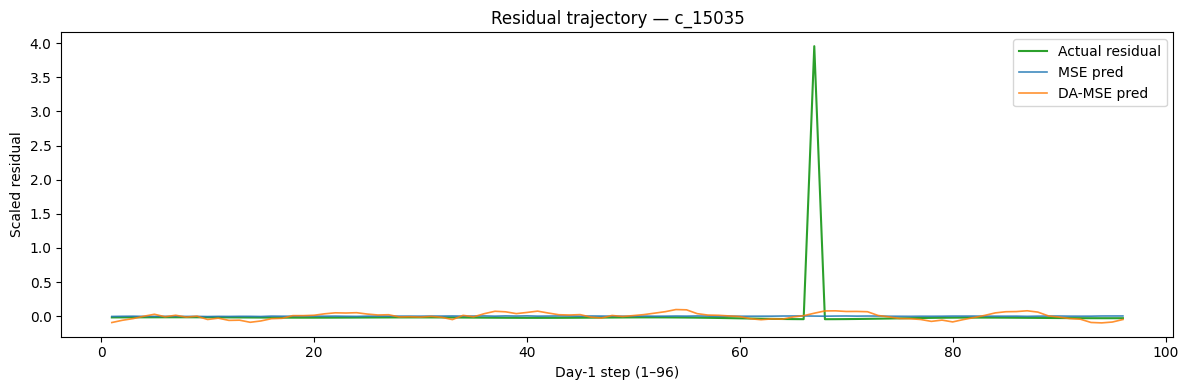

In [8]:
import matplotlib.pyplot as plt
import numpy as np

res = get_container_residuals(SELECTED_CONTAINER)
actual, pred_mse, pred_da = res['actual'], res['pred_mse'], res['pred_da']
steps = np.arange(1, len(actual) + 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, actual, label='Actual residual', lw=1.5, color='#2ca02c')
ax.plot(steps, pred_mse, label='MSE pred', lw=1.2, alpha=0.85)
ax.plot(steps, pred_da, label='DA-MSE pred', lw=1.2, alpha=0.85)
ax.set_xlabel('Day-1 step (1–96)')
ax.set_ylabel('Scaled residual')
ax.set_title(f'Residual trajectory — {SELECTED_CONTAINER}')
ax.legend()
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / f'trajectory_{SELECTED_CONTAINER}.png', dpi=150, bbox_inches='tight')
plt.show()


## 9 — Per-container distributions & horizon bands


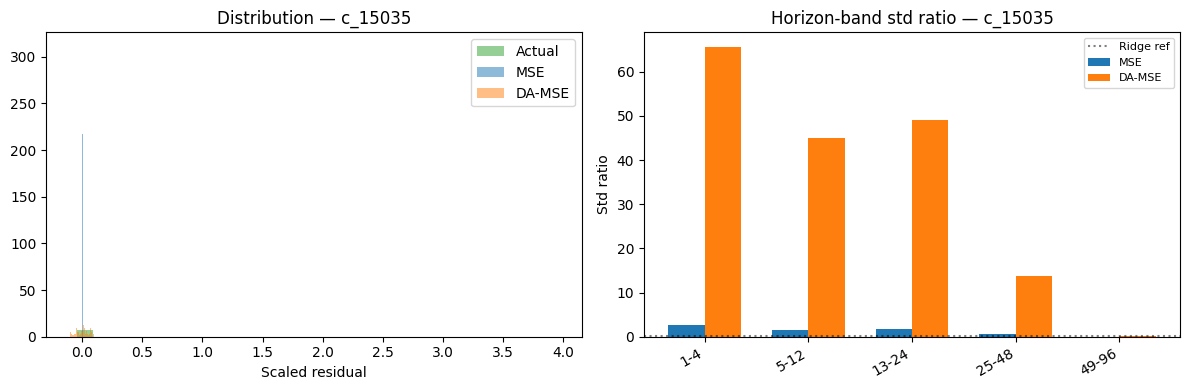

Horizon variance recovery (frozen diagnostic CSV):


arm,da_mse,mse
band,,
h01_12,46.217495,1.714577
h13_24,48.980694,1.811382
h25_48,13.679117,0.605151
h49_72,0.055263,0.001963
h73_96,12.144421,0.352438


Energy recovery ratio:


,arm,energy_recovery_ratio
78,mse,0.000027
177,da_mse,0.013878


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(actual, bins=30, alpha=0.5, label='Actual', density=True, color='#2ca02c')
axes[0].hist(pred_mse, bins=30, alpha=0.5, label='MSE', density=True)
axes[0].hist(pred_da, bins=30, alpha=0.5, label='DA-MSE', density=True)
axes[0].set_xlabel('Scaled residual')
axes[0].set_title(f'Distribution — {SELECTED_CONTAINER}')
axes[0].legend()

bands_mse = horizon_band_metrics(actual, pred_mse)
bands_da = horizon_band_metrics(actual, pred_da)
x = np.arange(len(bands_mse))
w = 0.35
axes[1].bar(x - w/2, bands_mse['std_ratio'], width=w, label='MSE')
axes[1].bar(x + w/2, bands_da['std_ratio'], width=w, label='DA-MSE')
axes[1].set_xticks(x, bands_mse['band'], rotation=30, ha='right')
axes[1].axhline(0.22, color='k', ls=':', alpha=0.5, label='Ridge ref')
axes[1].set_ylabel('Std ratio')
axes[1].set_title(f'Horizon-band std ratio — {SELECTED_CONTAINER}')
axes[1].legend(fontsize=8)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / f'container_detail_{SELECTED_CONTAINER}.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-container diagnostics from frozen CSVs
hv_row = hv_pc[(hv_pc['container_id'] == SELECTED_CONTAINER)]
ec_row = ec_pc[ec_pc['container_id'] == SELECTED_CONTAINER]
print('Horizon variance recovery (frozen diagnostic CSV):')
display(hv_row.pivot(index='band', columns='arm', values='std_ratio'))
print('Energy recovery ratio:')
display(ec_row[['arm', 'energy_recovery_ratio']])


## 10 — Training curves


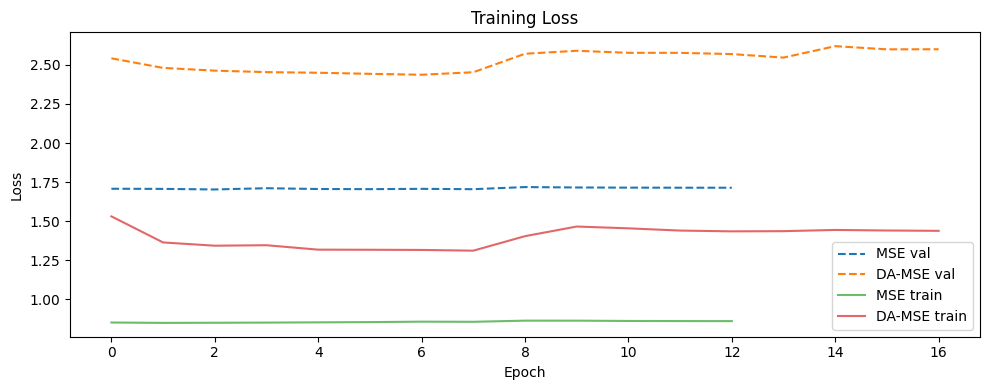

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mse_hist['val_loss'], label='MSE val', ls='--')
ax.plot(da_hist['val_loss'], label='DA-MSE val', ls='--')
ax.plot(mse_hist['loss'], label='MSE train', alpha=0.7)
ax.plot(da_hist['loss'], label='DA-MSE train', alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training Loss')
ax.legend(); plt.tight_layout(); plt.show()


## 11 — Cohort std ratio distribution


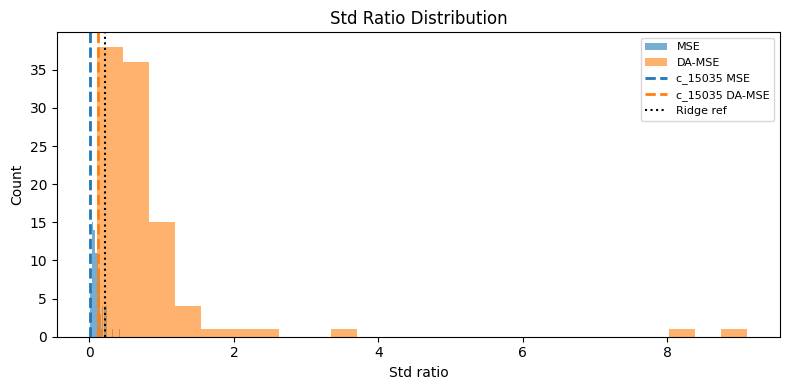

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mse_ext['residual_std_ratio'], bins=25, alpha=0.6, label='MSE')
ax.hist(da_ext['residual_std_ratio'], bins=25, alpha=0.6, label='DA-MSE')
if SELECTED_CONTAINER:
    sel_std_m = float(mse_ext.set_index('container_id').loc[SELECTED_CONTAINER, 'residual_std_ratio'])
    sel_std_d = float(da_ext.set_index('container_id').loc[SELECTED_CONTAINER, 'residual_std_ratio'])
    ax.axvline(sel_std_m, color='#1f77b4', ls='--', lw=2, label=f'{SELECTED_CONTAINER} MSE')
    ax.axvline(sel_std_d, color='#ff7f0e', ls='--', lw=2, label=f'{SELECTED_CONTAINER} DA-MSE')
ax.axvline(0.22, color='k', ls=':', label='Ridge ref')
ax.set_xlabel('Std ratio'); ax.set_ylabel('Count'); ax.set_title('Std Ratio Distribution')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 12 — Horizon-wise variance recovery (cohort)


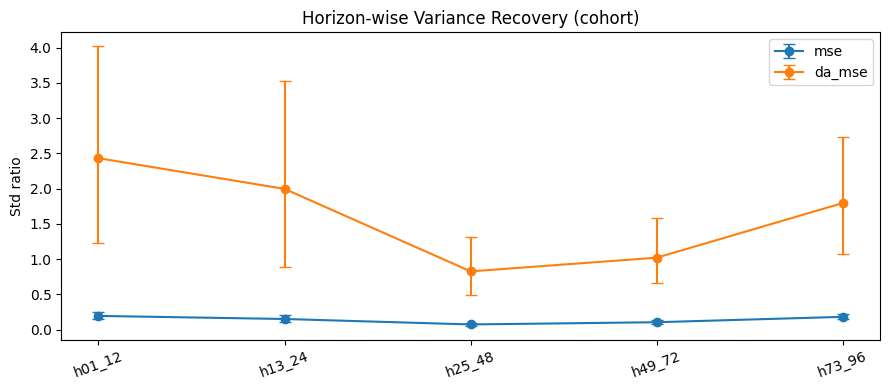

,arm,band,band_range,n,mean_std_ratio,median_std_ratio,ci_low,ci_high,n_flagged
0,da_mse,h01_12,1-12,99,2.430790,0.819480,1.222495,4.017345,0
1,da_mse,h13_24,13-24,99,1.995358,0.568390,0.886240,3.524301,0
2,da_mse,h25_48,25-48,99,0.825792,0.386785,0.484089,1.311030,0
3,da_mse,h49_72,49-72,99,1.019986,0.572986,0.657271,1.580079,0
4,da_mse,h73_96,73-96,99,1.794599,0.720668,1.066439,2.732737,0
5,mse,h01_12,1-12,99,0.194322,0.104873,0.145499,0.254744,0
6,mse,h13_24,13-24,99,0.150741,0.085382,0.107764,0.205593,0
7,mse,h25_48,25-48,99,0.073315,0.047471,0.057207,0.093249,0
8,mse,h49_72,49-72,99,0.104964,0.073989,0.080995,0.139621,0
9,mse,h73_96,73-96,99,0.181174,0.123471,0.144694,0.225918,0


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
for arm, color in [('mse', '#1f77b4'), ('da_mse', '#ff7f0e')]:
    sub = hv_cohort[hv_cohort['arm'] == arm]
    ax.errorbar(sub['band'], sub['mean_std_ratio'],
                yerr=[sub['mean_std_ratio']-sub['ci_low'], sub['ci_high']-sub['mean_std_ratio']],
                fmt='o-', capsize=4, label=arm, color=color)
ax.set_ylabel('Std ratio'); ax.set_title('Horizon-wise Variance Recovery (cohort)')
ax.legend(); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
display(hv_cohort)


## 13 — Residual energy recovery (cohort)


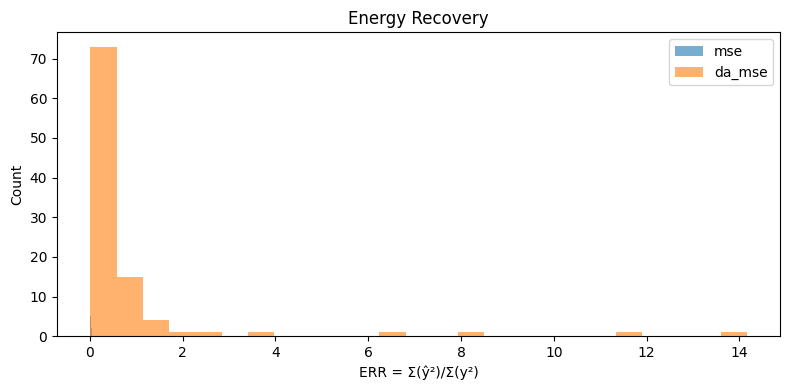

,arm,n,mean_err,median_err,ci_low,ci_high
0,da_mse,99,0.823230,0.311107,0.468590,1.274348
1,mse,99,0.010992,0.006381,0.008656,0.013498


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for arm, color in [('mse', '#1f77b4'), ('da_mse', '#ff7f0e')]:
    vals = ec_pc.loc[ec_pc['arm'] == arm, 'energy_recovery_ratio']
    ax.hist(vals, bins=25, alpha=0.6, label=arm, color=color)
ax.set_xlabel('ERR = Σ(ŷ²)/Σ(y²)'); ax.set_ylabel('Count'); ax.set_title('Energy Recovery')
ax.legend(); plt.tight_layout(); plt.show()
display(ec_cohort)


## 14 — Pre-exported experiment plots


energy_recovery_distribution.png


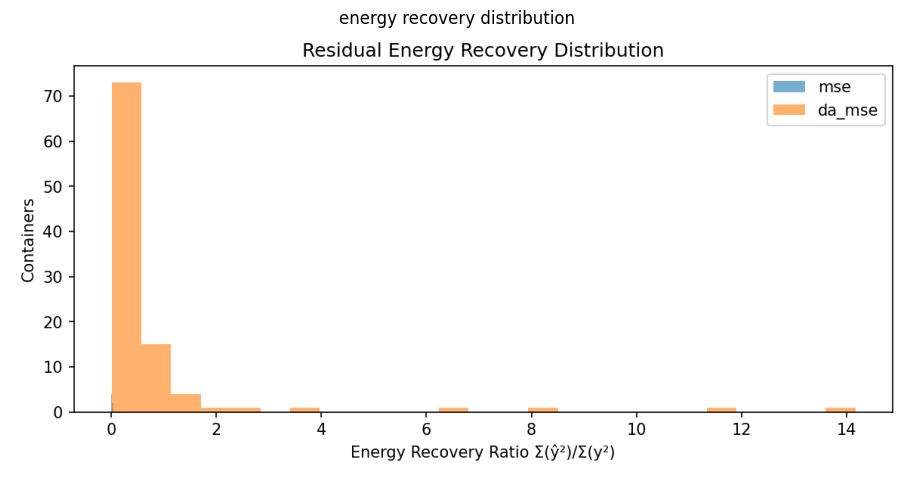

energy_recovery_mse_vs_da_mse_scatter.png


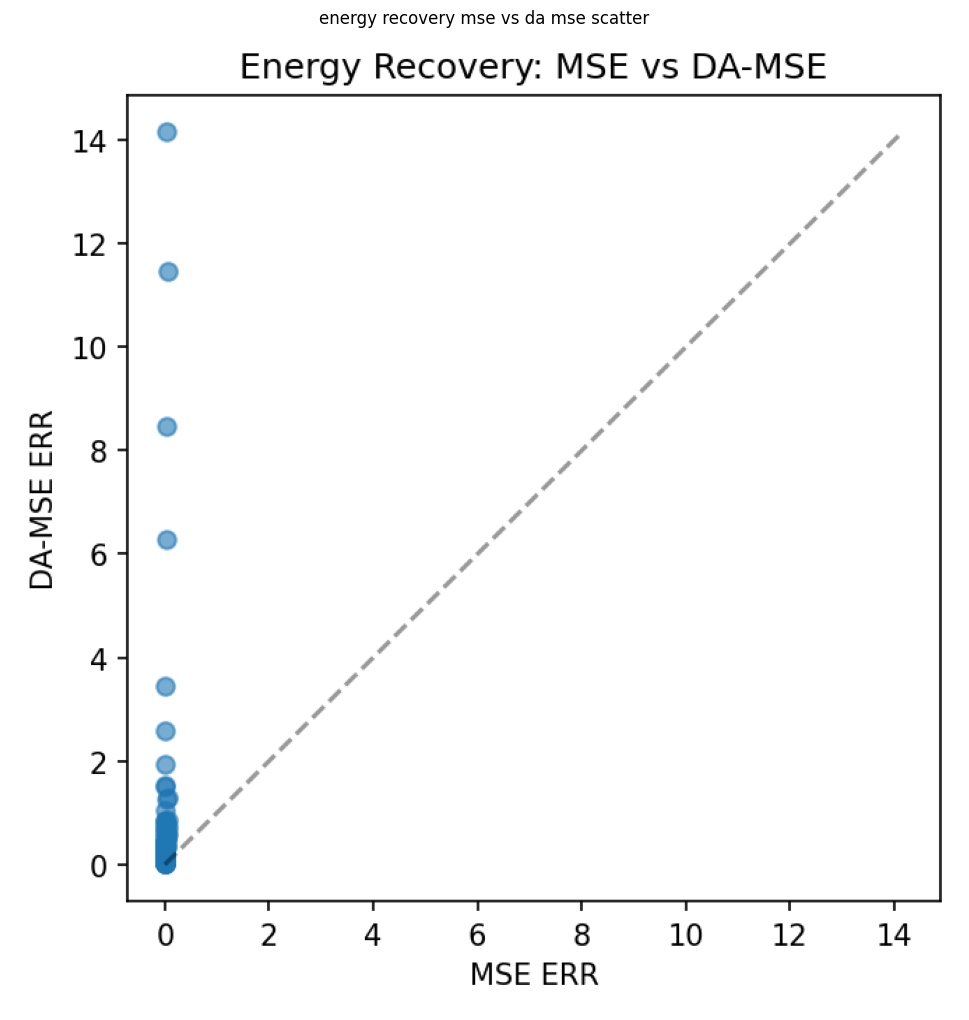

horizon_variance_recovery_boxplot.png


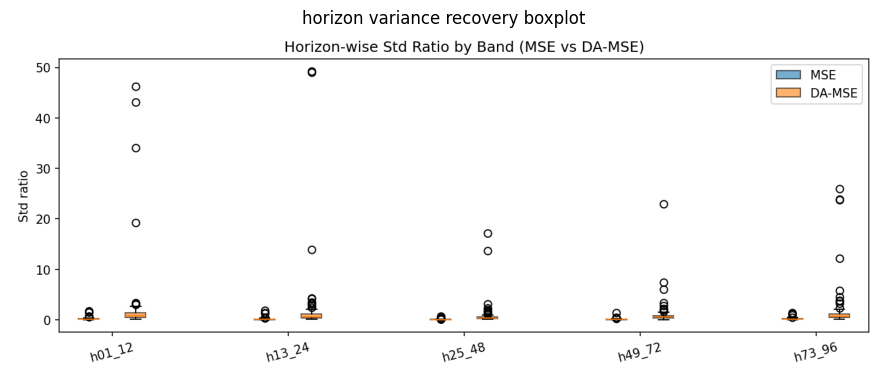

horizon_variance_recovery_mean_ci.png


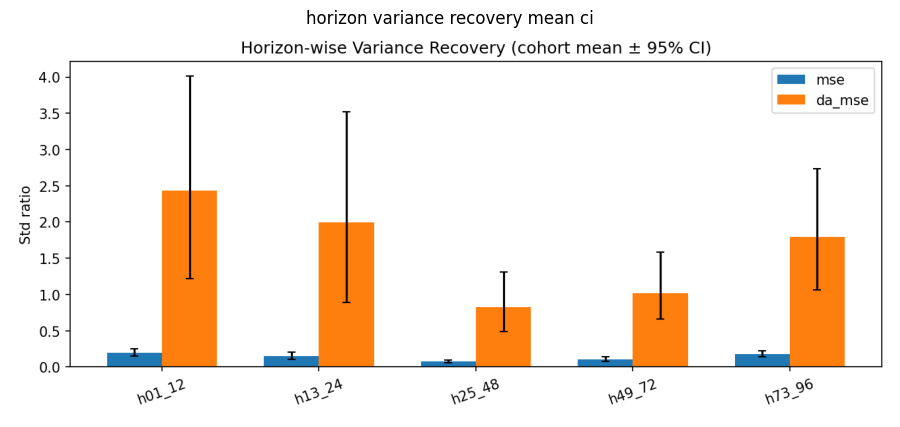

horizon_variance_recovery_mse_vs_da_mse.png


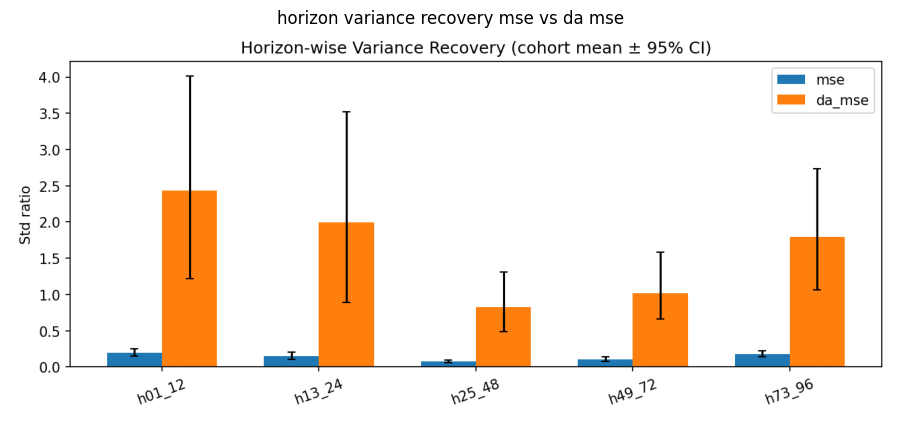

pearson_r_scatter.png


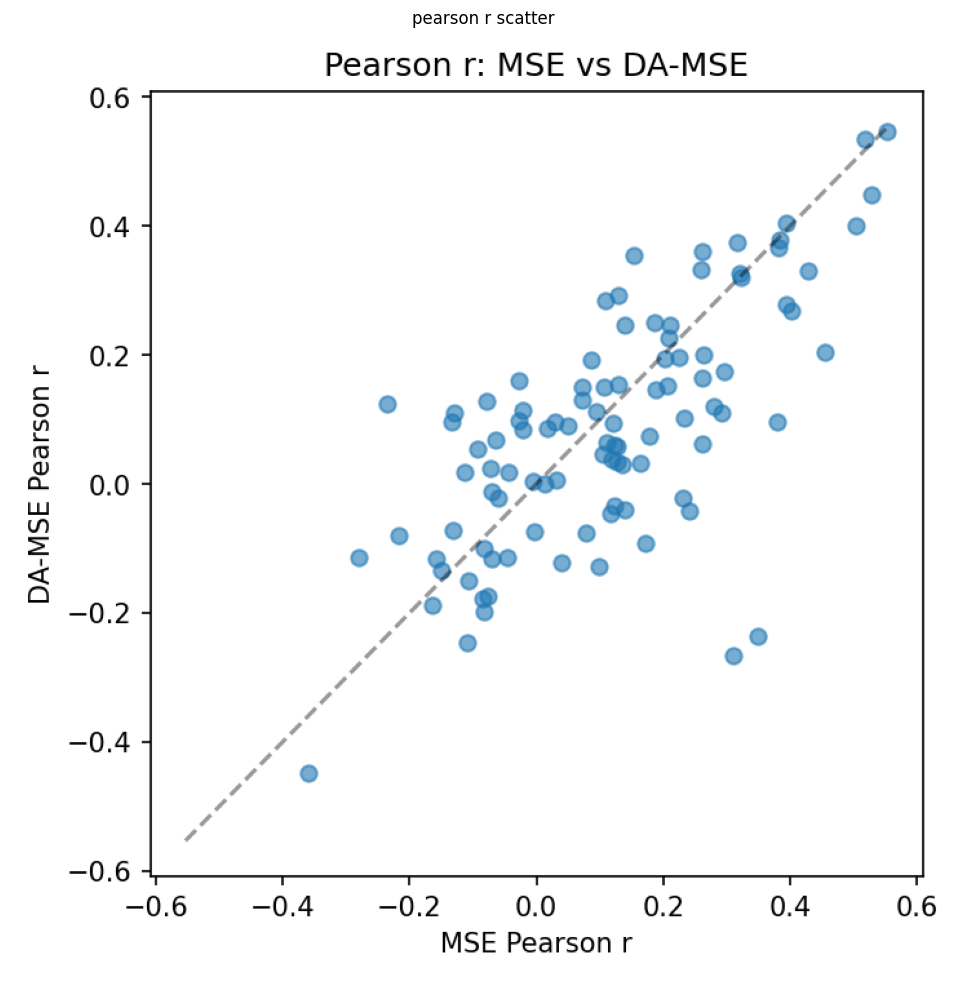

representative_trajectory_c_15035.png


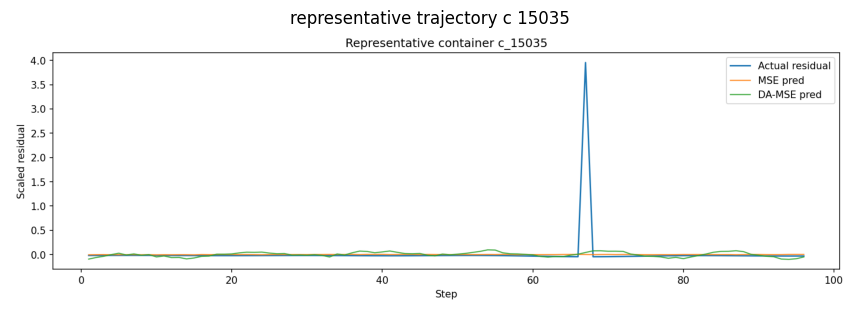

residual_histogram_da_mse.png


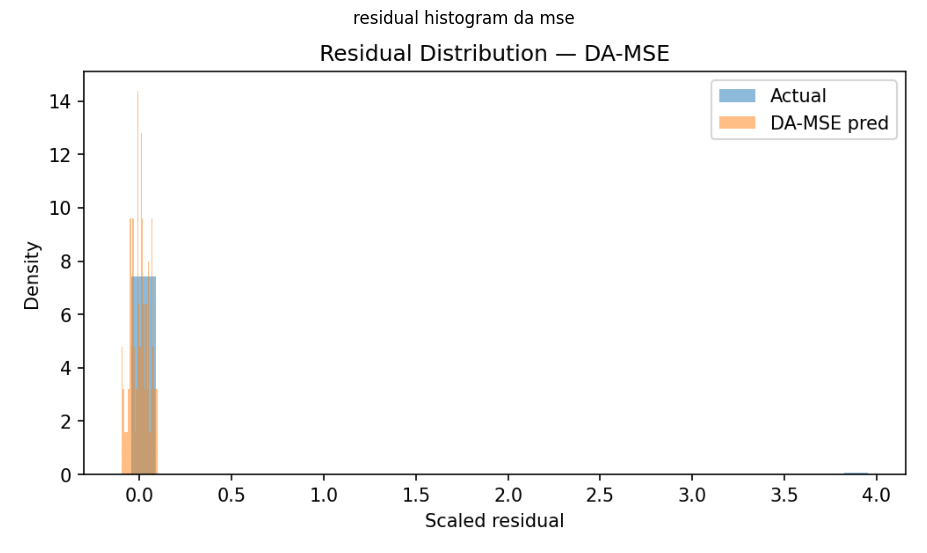

residual_histogram_mse.png


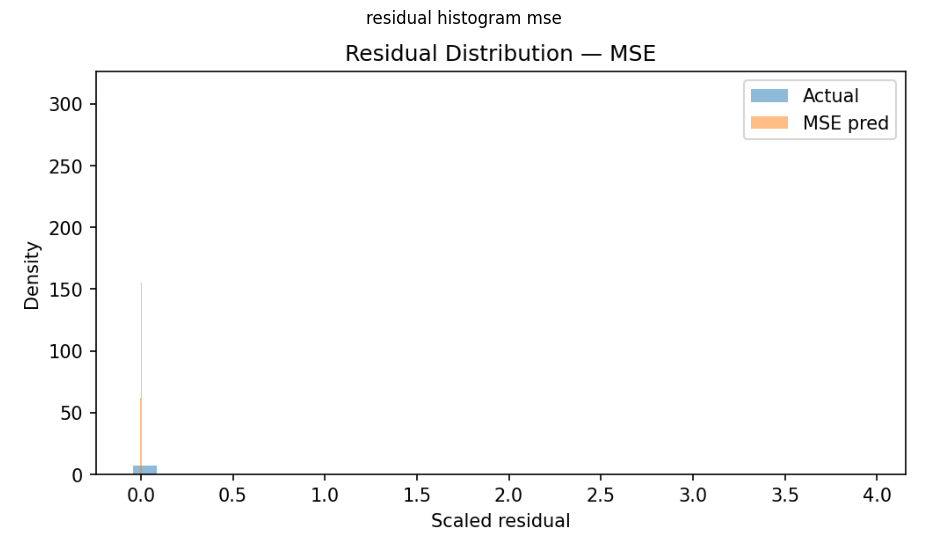

std_ratio_distribution.png


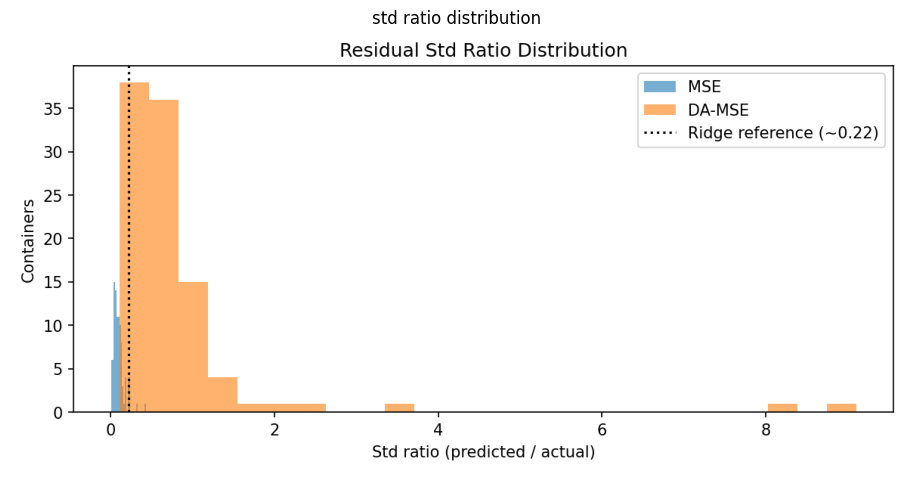

std_ratio_scatter.png


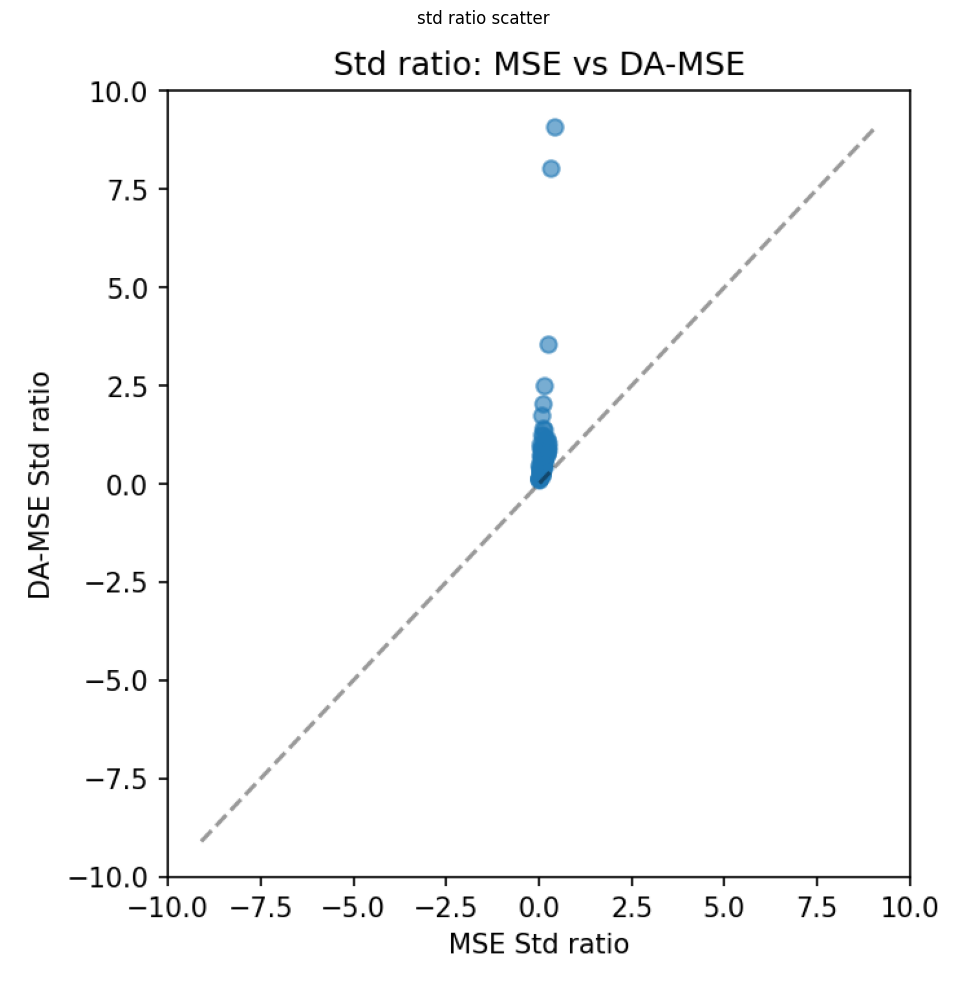

training_loss_comparison.png


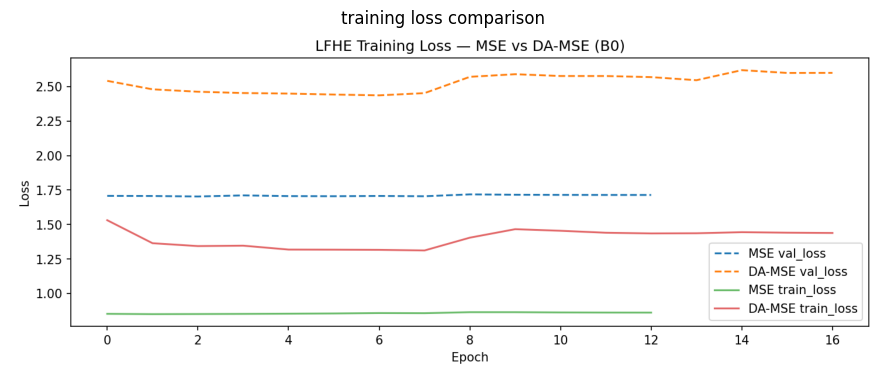

In [14]:
from utils.notebook_display import show_png_gallery

show_png_gallery(FIG_DIR)


## 15 — Metric comparison


In [15]:
metrics = ['residual_pearson_r', 'residual_std_ratio', 'residual_mae_scaled']
rows = []
for m in metrics:
    rows.append({'metric': m, 'mse': mse_ext[m].mean(), 'da_mse': da_ext[m].mean(),
                 'delta_da_minus_mse': da_ext[m].mean() - mse_ext[m].mean()})
display(pd.DataFrame(rows))


,metric,mse,da_mse,delta_da_minus_mse
0,residual_pearson_r,0.113331,0.087417,-0.025913
1,residual_std_ratio,0.100676,0.826784,0.726109
2,residual_mae_scaled,0.093231,0.104654,0.011423


## 16 — Hypothesis evaluation


In [16]:
v = final_report['hypothesis_verdict']
print('Verdict:', v['verdict'])
print('S1 dispersion recovery:', v['S1_dispersion'])
print('S2 correlation improvement:', v['S2_correlation'])
print('S3 MAE guardrail:', v['S3_mae_guardrail'])
print()
for q, a in final_report['explicit_answers'].items():
    print(f'{q}: {a}')


Verdict: inconclusive_I1
S1 dispersion recovery: True
S2 correlation improvement: False
S3 MAE guardrail: False

Q1_da_mse_reduce_variance_collapse: True
Q2_prediction_variance_increased: True
Q3_energy_recovery_improved: True
Q4_pearson_correlation_improved: False
Q5_cpu_forecasting_improved: False
Q6_hypothesis_supported: False
Q7_variance_collapse_explanation: Partial/inconclusive: inconclusive_I1
Q8_thesis_conclusion: inconclusive_I1


## 17 — Final conclusions


In [17]:
interp = final_report['diagnostic_interpretation']
print('MSE horizon band std ratios:', interp['mse_horizon_band_means'])
print('DA-MSE horizon band std ratios:', interp['da_horizon_band_means'])
print('Progressive MSE collapse across bands?', not interp['mse_approximately_flat_across_bands'])
print()
print(open(LFHE_EXP / 'reports' / 'final_report.md').read())


MSE horizon band std ratios: {'h01_12': 0.19432230913755547, 'h13_24': 0.15074080121190483, 'h25_48': 0.07331546895170647, 'h49_72': 0.10496383236038169, 'h73_96': 0.18117393929553097}
DA-MSE horizon band std ratios: {'h01_12': 2.4307895781044433, 'h13_24': 1.9953575958554355, 'h25_48': 0.8257917756732236, 'h49_72': 1.0199861732243425, 'h73_96': 1.794599059947737}
Progressive MSE collapse across bands? True

# LFHE Final Report

**Protocol:** lfhe_v1.1
**Timestamp:** 2026-07-26_130252

## Reproduction gate (MSE control vs Stage 2 B0)
- **Pass:** True

## Cohort metrics

| Metric | MSE | DA-MSE |
|--------|-----|--------|
| Pearson r | 0.1133 | 0.0874 |
| Std ratio | 0.1007 | 0.8268 |
| Residual MAE | 0.0932 | 0.1047 |
| Energy recovery | 0.0110 | 0.8232 |

## Hypothesis verdict
- **Verdict:** `inconclusive_I1`
- S1 dispersion: True
- S2 correlation: False
- S3 MAE guardrail: False

## Explicit answers

1. Did DA-MSE reduce variance collapse? **True**
2. Did prediction variance increase